In [1]:
!pip install pyspark

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("MobileSalesAnalysis") \
    .getOrCreate()

print("Spark Session Created")

Spark Session Created


In [3]:
from google.colab import files
uploaded = files.upload()

Saving synthetic_mobile_sales_2025.csv to synthetic_mobile_sales_2025 (1).csv


In [5]:
import os
os.listdir()

['.config',
 'synthetic_mobile_sales_2025 (1).csv',
 'synthetic_mobile_sales_2025.csv',
 'sample_data']

In [6]:
df = spark.read.csv(
    "synthetic_mobile_sales_2025.csv",
    header=True,
    inferSchema=True
)

df.show(5)

+-------+--------+-----------------+---------+-------+------+---------+----------+-----------+---------------+--------------+----------+---------+
|Sale_ID|   Brand|            Model|  Country|Storage| Color|Price_USD|Units_Sold|Revenue_USD|Customer_Rating|Payment_Method|Sale_Month|Sale_Year|
+-------+--------+-----------------+---------+-------+------+---------+----------+-----------+---------------+--------------+----------+---------+
|      1|  Realme|   Realme Model 2|       UK|  512GB|  Gold|      656|        20|      13120|            3.7|  Installments|        11|     2025|
|      2|    Vivo|    Vivo Model 20|Australia|  512GB|  Blue|     1013|         9|       9117|            3.7|    Debit Card|         2|     2025|
|      3|Motorola|Motorola Model 12|  Germany|  512GB| White|     1471|         7|      10297|            3.1|   Credit Card|         2|     2025|
|      4|    Vivo|    Vivo Model 13|      USA|  512GB|  Gold|     1220|        19|      23180|            3.6|    Debi

In [7]:
df.printSchema()
df.describe().show()

root
 |-- Sale_ID: integer (nullable = true)
 |-- Brand: string (nullable = true)
 |-- Model: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Storage: string (nullable = true)
 |-- Color: string (nullable = true)
 |-- Price_USD: integer (nullable = true)
 |-- Units_Sold: integer (nullable = true)
 |-- Revenue_USD: integer (nullable = true)
 |-- Customer_Rating: double (nullable = true)
 |-- Payment_Method: string (nullable = true)
 |-- Sale_Month: integer (nullable = true)
 |-- Sale_Year: integer (nullable = true)

+-------+-----------------+------+--------------+---------+-------+-----+-----------------+-----------------+-----------------+------------------+--------------+------------------+---------+
|summary|          Sale_ID| Brand|         Model|  Country|Storage|Color|        Price_USD|       Units_Sold|      Revenue_USD|   Customer_Rating|Payment_Method|        Sale_Month|Sale_Year|
+-------+-----------------+------+--------------+---------+-------+-----+---

In [8]:
from pyspark.sql.functions import col, count, when

df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
]).show()

+-------+-----+-----+-------+-------+-----+---------+----------+-----------+---------------+--------------+----------+---------+
|Sale_ID|Brand|Model|Country|Storage|Color|Price_USD|Units_Sold|Revenue_USD|Customer_Rating|Payment_Method|Sale_Month|Sale_Year|
+-------+-----+-----+-------+-------+-----+---------+----------+-----------+---------------+--------------+----------+---------+
|      0|    0|    0|      0|      0|    0|        0|         0|          0|              0|             0|         0|        0|
+-------+-----+-----+-------+-------+-----+---------+----------+-----------+---------------+--------------+----------+---------+



In [9]:
df.groupBy("Brand") \
  .sum("Revenue_USD") \
  .orderBy("sum(Revenue_USD)", ascending=False) \
  .show()

+--------+----------------+
|   Brand|sum(Revenue_USD)|
+--------+----------------+
|Motorola|          497446|
|  Huawei|          494360|
|    Vivo|          488657|
| Samsung|          486589|
|    Oppo|          484666|
|   Apple|          472552|
|  Google|          470623|
|  Xiaomi|          436357|
| OnePlus|          423516|
|  Realme|          384875|
+--------+----------------+



In [10]:
df.groupBy("Country") \
  .sum("Units_Sold") \
  .orderBy("sum(Units_Sold)", ascending=False) \
  .show()

+------------+---------------+
|     Country|sum(Units_Sold)|
+------------+---------------+
|   Australia|            687|
|         USA|            651|
|         UAE|            564|
|       India|            559|
|      France|            554|
|    Pakistan|            498|
|          UK|            479|
|     Germany|            427|
|      Canada|            414|
|Saudi Arabia|            396|
+------------+---------------+



In [11]:
from pyspark.sql.functions import avg

df.groupBy("Brand") \
  .agg(avg("Customer_Rating").alias("Average_Rating")) \
  .orderBy("Average_Rating", ascending=False) \
  .show()

+--------+------------------+
|   Brand|    Average_Rating|
+--------+------------------+
|  Huawei|             4.106|
|  Xiaomi| 4.099999999999999|
| Samsung|4.0470588235294125|
|    Vivo| 4.043103448275861|
|  Realme| 4.034693877551023|
|    Oppo| 4.030612244897959|
|  Google| 4.015384615384615|
| OnePlus|             3.975|
|Motorola| 3.967272727272728|
|   Apple|3.8979166666666654|
+--------+------------------+



In [12]:
df.groupBy("Sale_Month") \
  .sum("Revenue_USD") \
  .orderBy("Sale_Month") \
  .show()

+----------+----------------+
|Sale_Month|sum(Revenue_USD)|
+----------+----------------+
|         1|          343560|
|         2|          337167|
|         3|          507450|
|         4|          330569|
|         5|          280859|
|         6|          473153|
|         7|          411429|
|         8|          371536|
|         9|          380677|
|        10|          445441|
|        11|          416627|
|        12|          341173|
+----------+----------------+



In [13]:
df.groupBy("Payment_Method").count().show()

+--------------+-----+
|Payment_Method|count|
+--------------+-----+
|   Credit Card|  103|
|Online Payment|   94|
|          Cash|  107|
|  Installments|   95|
|    Debit Card|  101|
+--------------+-----+



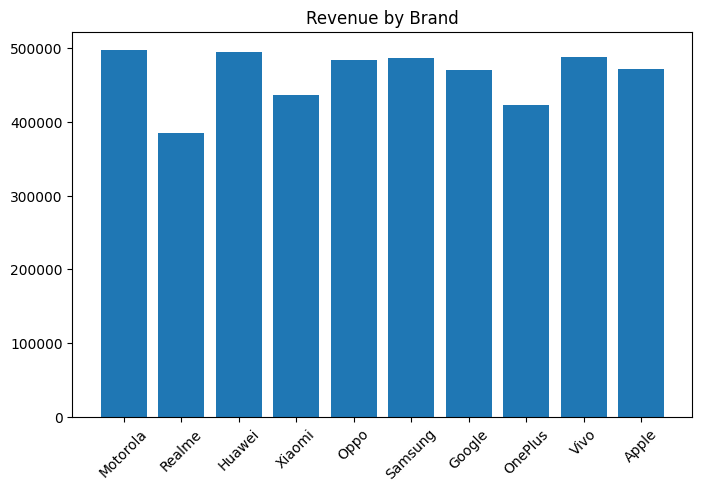

In [14]:
import matplotlib.pyplot as plt

pandas_df = df.groupBy("Brand").sum("Revenue_USD").toPandas()

plt.figure(figsize=(8,5))
plt.bar(pandas_df["Brand"], pandas_df["sum(Revenue_USD)"])
plt.xticks(rotation=45)
plt.title("Revenue by Brand")
plt.show()

Insights

Some mobile brands generate significantly higher revenue.

Sales differ across countries indicating regional demand.

Customer ratings remain consistently positive.

Digital payment methods dominate transactions.

Monthly sales show changing demand trends.
